# 2.1 Transit light curve analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2025-2026 exercise 2

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

## Initialisation

In [24]:
import math as mt
import pandas as pd
import warnings
import seaborn as sb
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, array, median, seterr, floor, percentile
from numpy.random import seed, permutation
from astropy.table import Table
from corner import corner

from pytransit import TransitLPF

seterr('ignore')
seed(0)

### Read in the data

First we need to read in the light curve stored in ``wasp-12b_181227_chromatic_k.fits``. The file has light curves for a single transit observed simultaneously in four passbands (g, r, i, and z_s), but we keep things simple and use only the r-band data. 

In our case, the photometry is saved as binary table extensions in the fits file, one extension per passband. To get the r-band data, we need to read the third HDU of the fits file (the first is the primary HDU, the second the first extension, etc.).

We start the same way as with the RV data and take a look at our data and try plotting it.

In [2]:
tb = Table.read('data/wasp-12b_181227_chromatic_k.fits', 2)
tb[:5]

time_bjd,flux,flux_rel,flux_trg,flux_ref,baseline,model
float64,float64,float64,float64,float64,float64,float64
2458480.557361179,1.0001350941062013,1.016282780690799,1.0234186998514527,1.0070215881802143,1.0161455054219737,1.0
2458480.558397079,1.0000222850175708,1.0167163747091499,1.0256873377854854,1.0088234667007323,1.0166937176717874,1.0
2458480.5587828704,0.999633046547194,1.0162828378132795,1.0244264276468822,1.0080131136044028,1.016655903207277,1.0
2458480.5594445122,1.0004227218395325,1.0169303171289636,1.0232086525273774,1.0061738108232814,1.016500620116942,1.0
2458480.5602084063,0.9981259684100012,1.0146302762017558,1.021813766379826,1.0070799091516973,1.0165352954577924,1.0


Now, we can assume the time data is stored in the ``time_bjd`` column and the flux the ``flux`` column. In general, if you'd see a file like this, you should check the file's documentation (if such exists) what column is what, or ask the person who created the file.

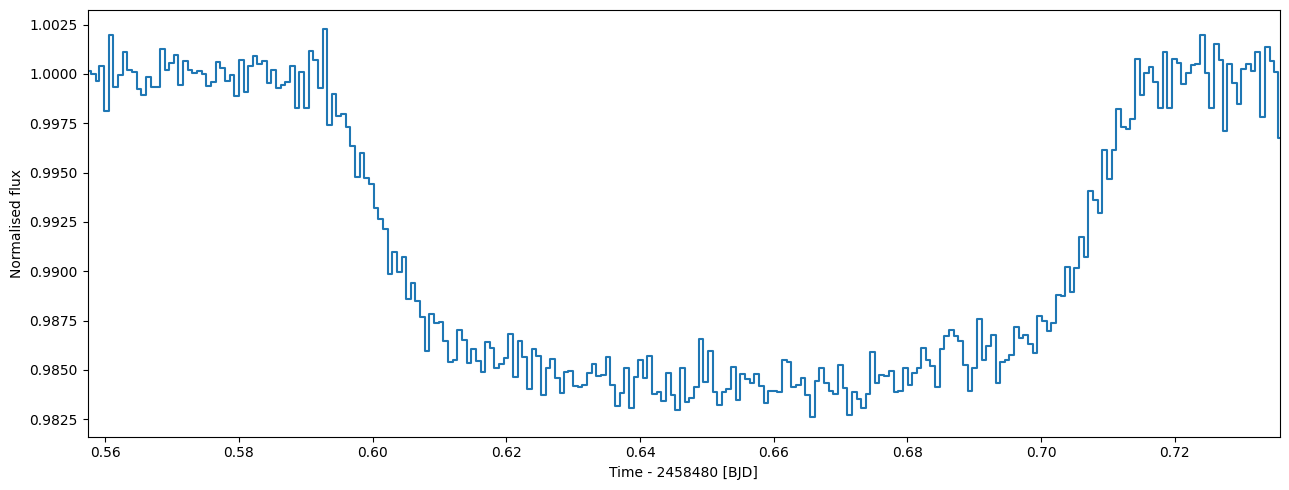

In [3]:
tref = floor(tb['time_bjd'].mean())
fig, ax = subplots(figsize=(13,5), sharey=True)
ax.plot(tb['time_bjd'] - tref, tb['flux'], drawstyle='steps-mid')
setp(ax, xlabel=f"Time - {tref:.0f} [BJD]", ylabel='Normalised flux', xlim=tb['time_bjd'][[0,-1]]-tref)
fig.tight_layout()

## Parameter estimation

First, we create an instance of the log posterior function with the redmost light curve data.

Next, we run the *DE* optimiser for ``de_iter`` iterations to clump the parameter vector population close to the global posterior maximum, use the *DE* population to initialise the *emcee* sampler, and run the sampler for ``mc_iter`` iterations to obtain a posterior sample.

### Initialise the LPF and set the priors

In [4]:
lpf = TransitLPF('WASP-12b', 'r', tb['time_bjd'], tb['flux'])
lpf.ps

[  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

In [5]:
lpf.set_prior('tc', 'NP', 2458480.65, 0.02)
lpf.set_prior('p', 'NP', 1.0914201, 1.1e-09)

In [6]:
lpf.ps

[  0 |G| tc             N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p              N(μ = 1.0914201, σ = 1.1e-09)            [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

Global optimisation:   0%|          | 0/500 [00:00<?, ?it/s]

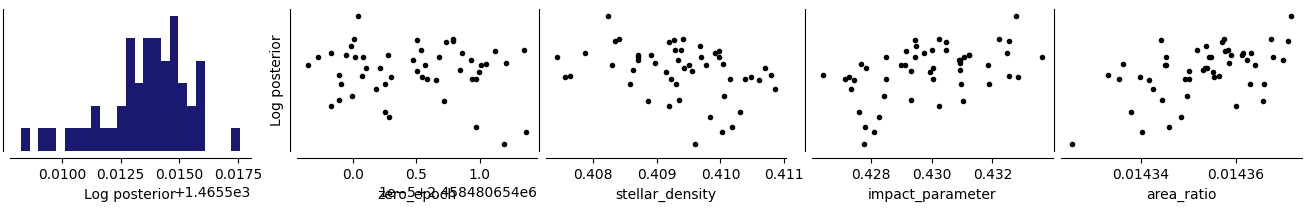

In [7]:
lpf.optimize_global(niter=500, npop=50)

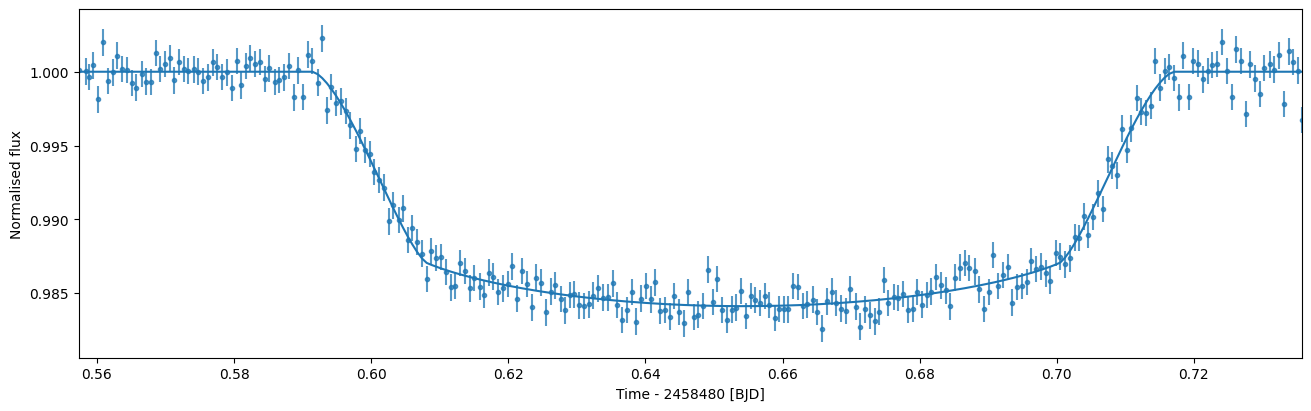

In [8]:
lpf.plot_light_curve();

In [9]:
lpf.sample_mcmc(5000, thin=20, repeats=2, label='MCMC sampling')

MCMC sampling:   0%|          | 0/2 [00:00<?, ?it/s]

Run 1/2:   0%|          | 0/5000 [00:00<?, ?it/s]

Run 2/2:   0%|          | 0/5000 [00:00<?, ?it/s]

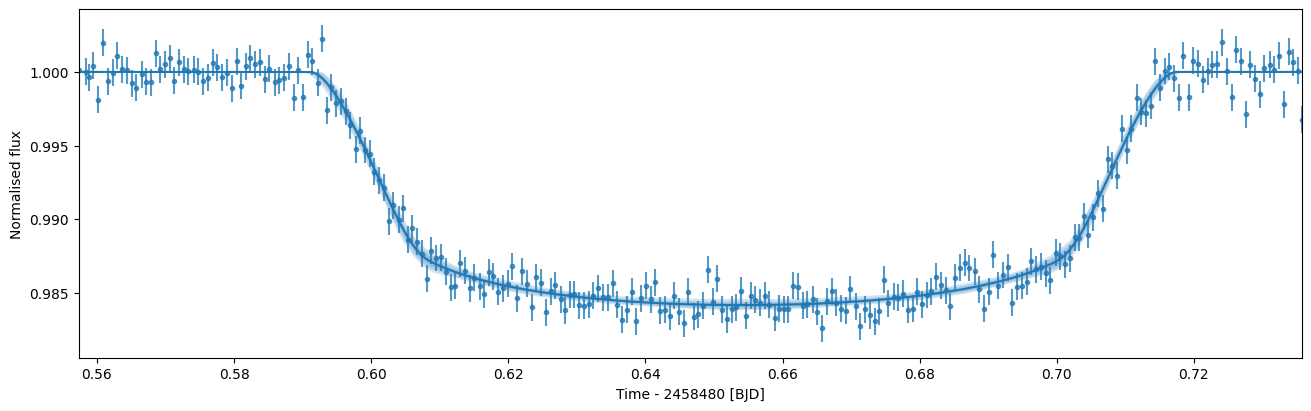

In [10]:
lpf.plot_light_curve('mc');

### Analysis: overview

The MCMC chains are now stored in ``lpf.sampler.chain``. Let's first have a look into how the chain populations evolved to see if we have any problems with our setup, whether we have converged to sample the true posterior distribution, and, if so, what was the burn-in time.

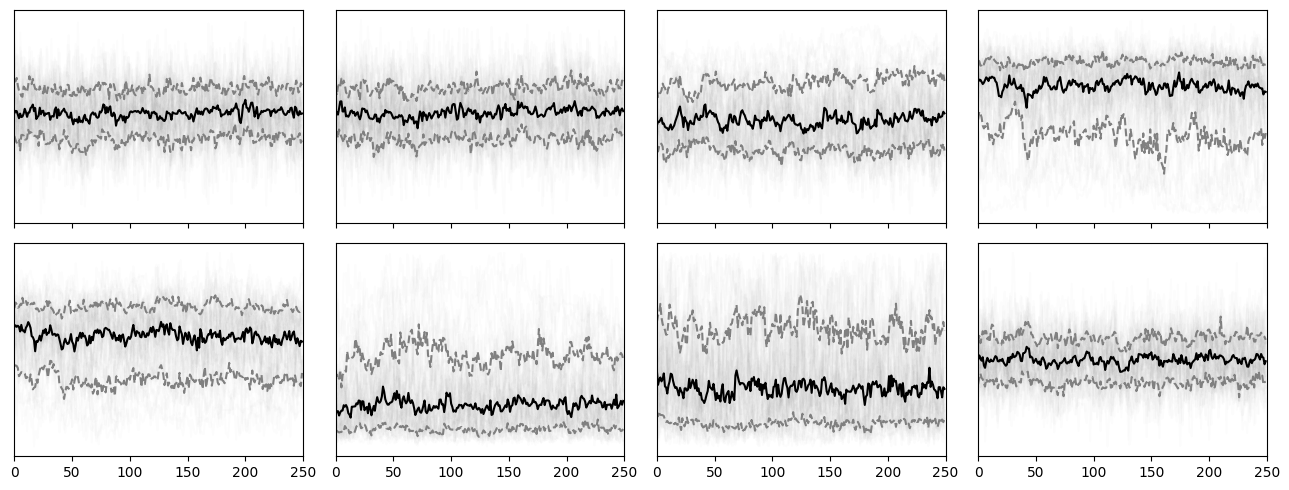

In [11]:
fig, axs = subplots(2,4, figsize=(13,5), sharex=True)
ls, lc = ['-','--','--'], ['k', '0.5', '0.5']
percs = [percentile(lpf.sampler.chain[:,:,i], [50,16,84], 0) for i in range(8)]
[axs.flat[i].plot(lpf.sampler.chain[:,:,i].T, 'k', alpha=0.01) for i in range(8)]
[[axs.flat[i].plot(percs[i][j], c=lc[j], ls=ls[j]) for j in range(3)] for i in range(8)]
setp(axs, yticks=[], xlim=[0,5000//20])
fig.tight_layout()

Ok, everything looks good. The 16th, 50th and 84th percentiles of the parameter vector population are stable and don't show any significant long-term trends. Now we can flatten the individual chains into one long chain ``fc`` and calculate the median parameter vector.

In [12]:
fc = lpf.sampler.chain.reshape([-1,lpf.sampler.chain.shape[-1]])
mp = median(fc, 0)

Let's also plot the model and the data to see if this all makes sense. To do this, we calculate the conditional distribution of flux using the posterior samples (here, we're using a random subset of samples, although this isn't really necessary), and plot the distribution median and it's median-centred 68%, 95%, and 99.7% central posterior intervals (corresponding approximately to 1, 2, and 3$\sigma$ intervals if the distribution is normal). 

In [13]:
flux_pr = lpf.flux_model(fc[permutation(fc.shape[0])[:1000]])
flux_pc = array(percentile(flux_pr, [50, 0.15,99.85, 2.5,97.5, 16,84], 0))

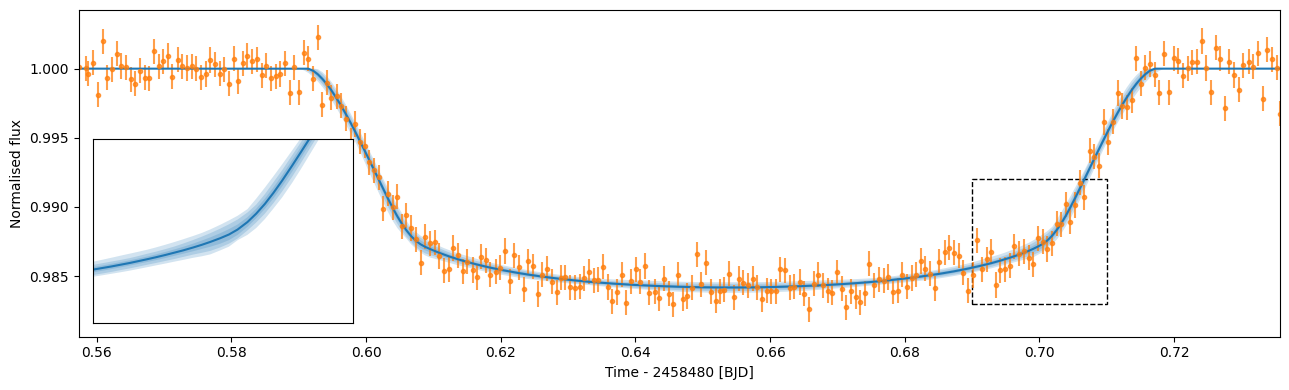

In [14]:
zx1,zx2,zy1,zy2 = 0.69,0.71, 0.983, 0.992
tref = floor(lpf.timea.min())
fig, ax = subplots(1,1, figsize=(13,4))
ax.errorbar(lpf.timea-tref, lpf.ofluxa, 10**mp[7], fmt='.', c='C1', alpha=0.75)
[ax.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
ax.plot(lpf.timea-tref, flux_pc[0], c='C0')
setp(ax, xlim=lpf.timea[[0,-1]]-tref, xlabel=f'Time - {tref:.0f} [BJD]', ylabel='Normalised flux')
fig.tight_layout()

az = fig.add_axes([0.075,0.18,0.20,0.46])
ax.add_patch(Rectangle((zx1,zy1),zx2-zx1,zy2-zy1,fill=False,edgecolor='k',lw=1,ls='dashed'))
[az.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
setp(az, xlim=(zx1,zx2), ylim=(zy1,zy2), yticks=[], xticks=[])
az.plot(lpf.timea-tref, flux_pc[0], c='C0');

We could (should) also plot the residuals, but I've left them out from the plot for clarity. The plot looks fine, and we can continue to have a look at the parameter estimates.

## Analysis

We start the analysis by making a Pandas data frame ``df``, using the ``df.describe`` to gen an overview of the estimates, and plotting the posteriors for the most interesting parameters as violin plots.

In [15]:
pd.set_option('display.precision',4)
df = lpf.posterior_samples(derived_parameters=True)
df.describe()

,tc,p,rho,b,k2,q1_r,q2_r,wn_loge_0,k,a,inc,t14,t23
count,1.2500e+04,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000
mean,2.4585e+06,1.0914e+00,0.4325,0.3445,0.0140,0.3072,0.3539,-3.0411,0.1182,3.0066,1.4548,0.1258,0.0945
std,1.6555e-04,1.0714e-09,0.0355,0.1159,0.0004,0.1927,0.2390,0.0194,0.0019,0.0820,0.0411,0.0010,0.0025
min,2.4585e+06,1.0914e+00,0.3297,0.0001,0.0127,0.0471,0.0002,-3.1117,0.1126,2.7483,1.3618,0.1224,0.0866
25%,2.4585e+06,1.0914e+00,0.4062,0.2873,0.0137,0.1594,0.1604,-3.0542,0.1169,2.9464,1.4248,0.1251,0.0925
50%,2.4585e+06,1.0914e+00,0.4293,0.3757,0.0141,0.2522,0.2993,-3.0413,0.1186,3.0013,1.4453,0.1258,0.0942
75%,2.4585e+06,1.0914e+00,0.4578,0.4291,0.0143,0.4132,0.5054,-3.0282,0.1197,3.0664,1.4769,0.1265,0.0964
max,2.4585e+06,1.0914e+00,0.5373,0.5704,0.0151,0.9995,1.0000,-2.9537,0.1228,3.2344,1.5708,0.1298,0.1014


<Axes: >

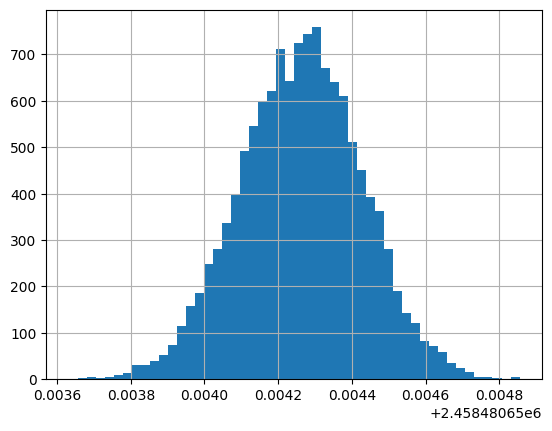

In [16]:
df.tc.hist(bins=50)

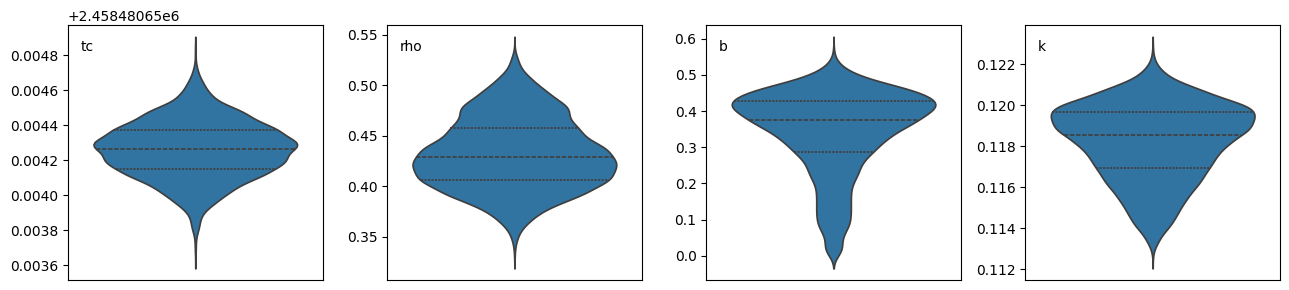

In [17]:
fig, axs = subplots(1,4, figsize=(13,3))
pars = 'tc rho b k'.split()
[sb.violinplot(y=df[p], inner='quartile', ax=axs.flat[i]) for i,p in enumerate(pars)]
[axs.flat[i].text(0.05,0.9, p, transform=axs.flat[i].transAxes) for i,p in enumerate(pars)]
setp(axs, xticks=[], ylabel='')
fig.tight_layout()

While we're at it, let's plot some correlation plots. The limb darkening coefficients are correlated, and we'd also expect to see a correlation between the impact parameter and radius ratio.

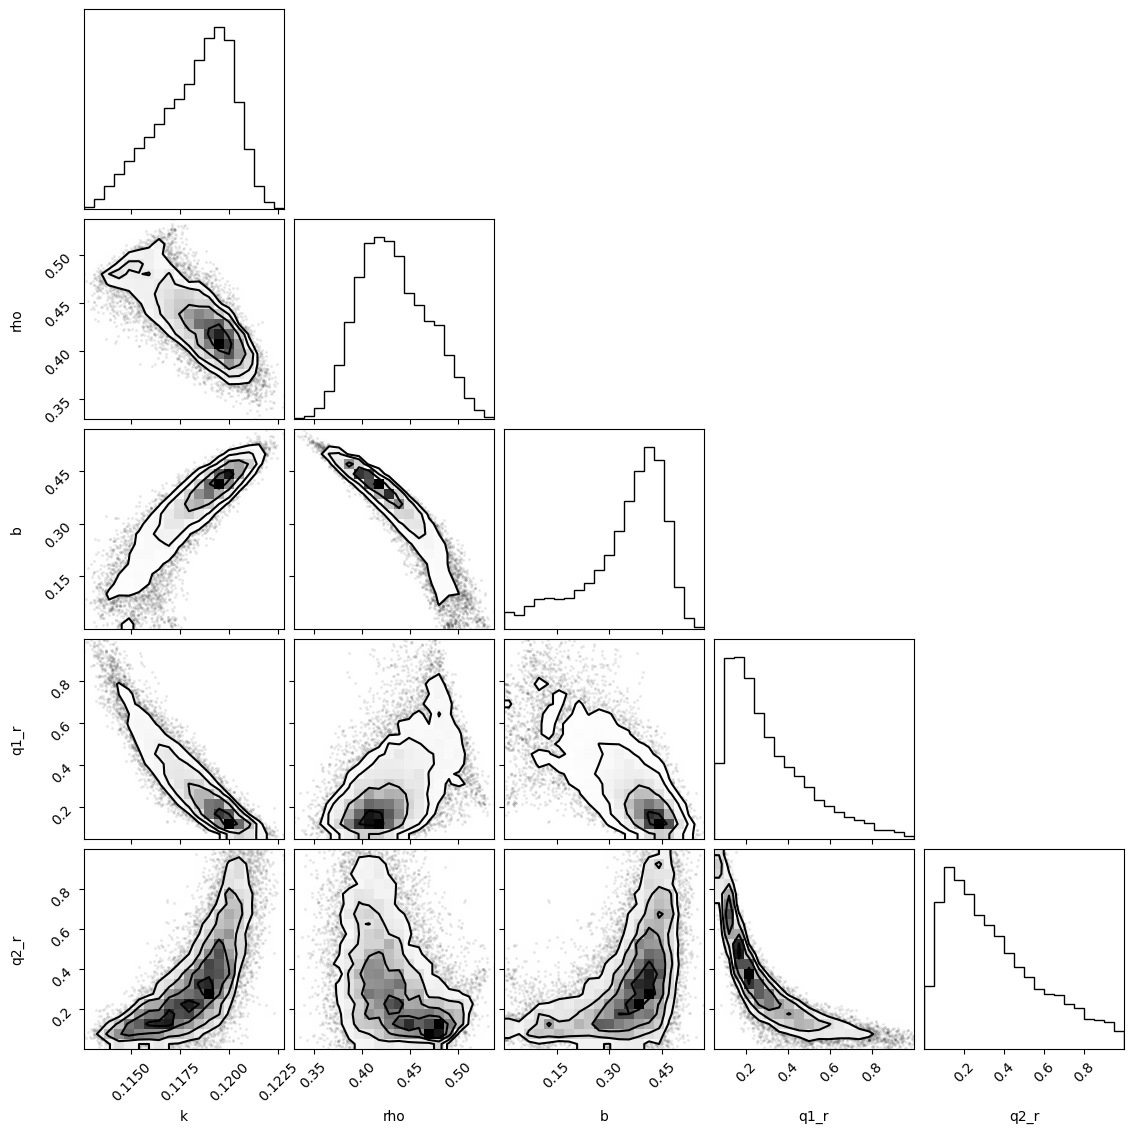

In [18]:
ccols = ['k', 'rho', 'b', 'q1_r', 'q2_r']
corner(df[ccols].values, labels=ccols);

### <span style="color:darkblue">Questions and exercises</span>

1. Estimate the radius of the planet using the planet-star radius ratio (k) and the stellar radius (that you need to find from somewhere) Give the answer in Jupiter radii.

In [26]:
k_1 = df['k'].values
R_star = 1.66 * u.R_sun
R_planet = k_1 * R_star
R_planet_jup = R_planet.to(u.R_jup)

r_values = R_planet_jup.value
median_r = np.percentile(r_values, 50)
lower_r = median_r - np.percentile(r_values, 16)
upper_r = np.percentile(r_values, 84) - median_r

print(f"Planetary Radius of WASP-12b:")
print(f"{median_r:.3f} +{upper_r:.3f} / -{lower_r:.3f} R_Jup")

Planetary Radius of WASP-12b:
1.915 +0.025 / -0.039 R_Jup


2. Estimate the planet's bulk density based on the radius posterior and exercise 1 minimum mass estimate. Include the minimum mass estimate's uncertainty into the calculation.

In [27]:
mass_values = np.random.normal(loc=1.358, scale=0.012, size=len(k_post))
M_planet = mass_values * u.M_jup

V_planet = (4/3) * np.pi * R_planet**3

density = M_planet / V_planet
density_cgs = density.to(u.g / u.cm**3)

d_values = density_cgs.value
median_d = np.percentile(d_values, 50)
lower_d = median_d - np.percentile(d_values, 16)
upper_d = np.percentile(d_values, 84) - median_d

print("Planetary Bulk Density of WASP-12b:")
print(f"{median_d:.3f} +{upper_d:.3f} / -{lower_d:.3f} g/cm^3")

Planetary Bulk Density of WASP-12b:
0.240 +0.015 / -0.010 g/cm^3


3. Why can we use the minimum mass estimate from RVs as a true mass estimate after a transit observation? Would there be better ways to estimate planetary properties than by modelling RVs and photometry separately?

- Answer:

The radial velocity method alone only yields the minimum mass ($M_p \sin i$) because the orbital inclination ($i$) relative to the observer is unknown. However, observing a planetary transit geometrically requires the planet to pass directly between the host star and the observer. This implies that the orbit must be viewed almost perfectly edge-on, meaning the inclination is very close to $90^\circ$. Since $\sin(90^\circ) = 1$, the $\sin i$ term vanishes ($M_p \sin i \approx M_p \times 1$), allowing us to safely assume that the RV minimum mass is the true physical mass of the planet.

Yes, a better approach is to perform a simultaneous fitting of both the radial velocity and photometric transit datasets within a single MCMC framework.
Rather than modeling them independently, a joint fit links the shared physical parameters that influence both datasets (such as the orbital period $P$, eccentricity $e$, argument of periastron $\omega$, and the time of transit $T_c$). This simultaneous constraint provides a much more robust and self-consistent physical model of the planetary system.
   
4. What can you say about WASP-12b as a planet based on its orbirtal period, radius, mass, and bulk density?

- Answer:

Based on the combination of these four parameters, WASP-12b can be classified as an Inflated Hot Jupiter (often referred to as a "puffy planet").
- Mass ($\sim 1.36 \ M_{Jup}$) & Period ($\sim 1.09$ days): These values confirm it is a gas giant residing in an ultra-short orbit, placing it extremely close to its host star.
- Radius ($\sim 1.91 \ R_{Jup}$) & Bulk Density ($\sim 0.24 \ \text{g/cm}^3$): Despite having a mass comparable to Jupiter, its radius is almost twice as large, leading to an exceptionally low bulk density.

The extreme proximity to the host star subjects WASP-12b to immense stellar irradiation. This extreme heat energy is deposited into the planet's gaseous envelope, causing the atmosphere to thermally expand (inflate) to a massive radius. Because of this severe inflation and close orbit, the planet's outer layers are weakly bound by its own gravity, making it highly susceptible to atmospheric escape (mass loss) driven by the star's tidal forces and stellar winds.

5. Compare the stellar density ($\rho$) estimated from the transit modelling to the theoretical stellar density for a WASP-12-like star.

- Answer:

In [28]:
rho_1 = df['rho'].values
median_rho_obs = np.percentile(rho_1, 50)
lower_rho_obs = median_rho_obs - np.percentile(rho_1, 16)
upper_rho_obs = np.percentile(rho_post, 84) - median_rho_obs

M_star = 1.35 * u.M_sun
R_star = 1.66 * u.R_sun
V_star = (4/3) * np.pi * R_star**3
rho_theory = (M_star / V_star).to(u.g / u.cm**3)

print(f"1. Estimated Stellar Density (Transit Model):")
print(f"   {median_rho_obs:.3f} +{upper_rho_obs:.3f} / -{lower_rho_obs:.3f} g/cm^3\n")

print(f"2. Theoretical Stellar Density (M=1.35 M_sun, R=1.66 R_sun):")
print(f"   {rho_theory.value:.3f} g/cm^3")

1. Estimated Stellar Density (Transit Model):
   0.429 +0.043 / -0.033 g/cm^3

2. Theoretical Stellar Density (M=1.35 M_sun, R=1.66 R_sun):
   0.416 g/cm^3


Conclusion:

The stellar density estimated purely from the photometry of the transit model ($0.429 \ \text{g/cm}^3$) is in excellent agreement with the theoretical density ($0.416 \ \text{g/cm}^3$). This strong match confirms that the planetary system is physically well-behaved, supports the initial assumption of a circular orbit ($e \approx 0$), and validates that our transit MCMC fit is highly robust.

6. From the plot above you can see that many of the parameters are correlated with each other. What does this mean in practice?

- Answer:

In practice, parameter correlation indicates parameter degeneracy. This means that multiple different combinations of these parameters can produce an almost identical transit light curve that fits the data equally well.

Looking at the specific contours in the plot, we can observe some transit degeneracies:
- $b$ vs. $k$ (Positive correlation): The contour slopes upwards. If the planet transits closer to the stellar limb (a higher impact parameter, $b$), the stellar flux is lower due to limb darkening, and the transit chord is shorter. To match the observed depth of the transit in the data, the model must compensate by assuming a larger planetary radius ($k$).
- $b$ vs. $\rho$ (Negative correlation): The contour curves downwards. A higher impact parameter implies a geometrically shorter transit path. To match the actual observed transit duration, the model must compensate by artificially lowering the stellar density ($\rho$).
    
Practical implications:Because these parameters are deeply coupled, we cannot treat their uncertainties independently. If the true value of one parameter shifts, the most likely values for $b$ and $k$ must also shift along these correlation axes.

---
<center>&copy;2026 Hannu Parviainen</center>